In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder


df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

# KPI Calculation
total_employees = len(df)
attrition_count = df[df['Attrition'] == 'Yes'].shape[0]
attrition_rate = (attrition_count / total_employees) * 100

print(f"Total Employees: {total_employees}")
print(f"Current Attrition Rate: {attrition_rate:.2f}%")


df = df.drop(['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber'], axis=1)

Total Employees: 1470
Current Attrition Rate: 16.12%


In [ ]:
# LabelEncoder object
le = LabelEncoder()


for column in df.columns:
    if df[column].dtype == object:
        df[column] = le.fit_transform(df[column])

print(df.head())

   Age  Attrition  BusinessTravel  DailyRate  Department  DistanceFromHome  \
0   41          1               2       1102           2                 1   
1   49          0               1        279           1                 8   
2   37          1               2       1373           1                 2   
3   33          0               1       1392           1                 3   
4   27          0               2        591           1                 2   

   Education  EducationField  EnvironmentSatisfaction  Gender  ...  \
0          2               1                        2       0  ...   
1          1               1                        3       1  ...   
2          2               4                        4       1  ...   
3          4               1                        4       0  ...   
4          1               3                        1       1  ...   

   PerformanceRating  RelationshipSatisfaction  StockOptionLevel  \
0                  3                      

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# data into Features (X) and Target (y)
X = df.drop('Attrition', axis=1)
y = df['Attrition']

# stratify=y keeps the same attrition ratio in train and test — important since attrition is imbalanced
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print("Model Accuracy:", accuracy_score(y_test, predictions))

Model Accuracy: 0.8435374149659864


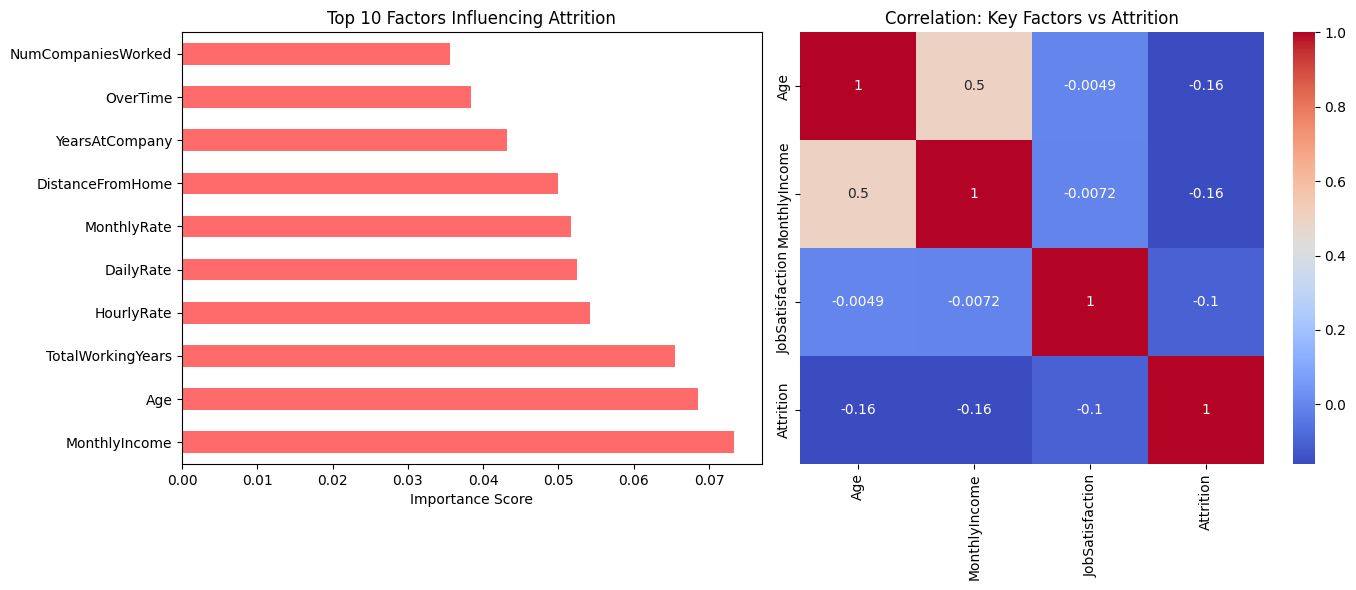

In [ ]:
# Calculate (The "Why")
importances = pd.Series(model.feature_importances_, index=X.columns)

# Plotting Dashboard
plt.figure(figsize=(14, 6))

# Subplot 1: Top 10 Drivers of Attrition
plt.subplot(1, 2, 1)
importances.nlargest(10).plot(kind='barh', color='#FF6B6B')
plt.title("Top 10 Factors Influencing Attrition")
plt.xlabel("Importance Score")

# Subplot 2: Correlation Matrix
plt.subplot(1, 2, 2)
sns.heatmap(df[['Age', 'MonthlyIncome', 'JobSatisfaction', 'Attrition']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation: Key Factors vs Attrition")

plt.tight_layout()
plt.show()

Precision: 0.545
Recall:    0.128
F1-score:  0.207

Full report:
               precision    recall  f1-score   support

           0       0.86      0.98      0.91       247
           1       0.55      0.13      0.21        47

    accuracy                           0.84       294
   macro avg       0.70      0.55      0.56       294
weighted avg       0.81      0.84      0.80       294



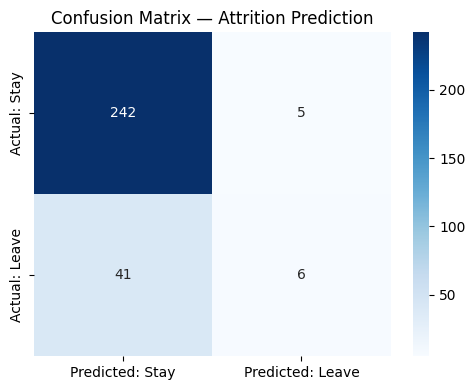

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# core evaluation metrics
prec = precision_score(y_test, predictions)
rec = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)

print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1-score:  {f1:.3f}")
print("\nFull report:\n", classification_report(y_test, predictions))

# confusion matrix: rows = actual class, columns = predicted class
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted: Stay', 'Predicted: Leave'],
    yticklabels=['Actual: Stay', 'Actual: Leave']
)
plt.title('Confusion Matrix — Attrition Prediction')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

Accuracy:  0.837
Precision: 0.444
Recall:    0.085
F1-score:  0.143


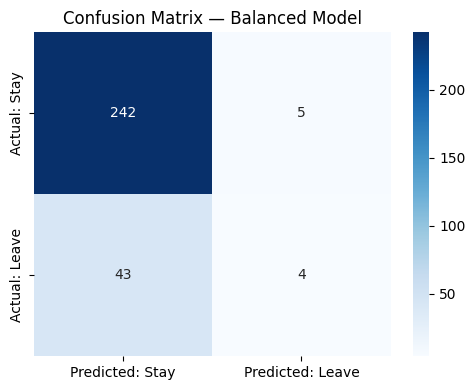

In [ ]:
# Retrain with class_weight='balanced' to address the imbalance seen in the confusion matrix
model_balanced = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model_balanced.fit(X_train, y_train)

predictions_balanced = model_balanced.predict(X_test)

prec_bal = precision_score(y_test, predictions_balanced)
rec_bal = recall_score(y_test, predictions_balanced)
f1_bal = f1_score(y_test, predictions_balanced)

print(f"Accuracy:  {accuracy_score(y_test, predictions_balanced):.3f}")
print(f"Precision: {prec_bal:.3f}")
print(f"Recall:    {rec_bal:.3f}")
print(f"F1-score:  {f1_bal:.3f}")

cm_balanced = confusion_matrix(y_test, predictions_balanced)
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_balanced, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted: Stay', 'Predicted: Leave'],
    yticklabels=['Actual: Stay', 'Actual: Leave']
)
plt.title('Confusion Matrix — Balanced Model')
plt.tight_layout()
plt.savefig('confusion_matrix_balanced.png', dpi=150)
plt.show()